## Gradient Boosting with XGBoost and LightGBM

Gradient boosting combines numerous small Decision Tree models to make predictions. Of course, those small decision trees are different from each other; else, there wouldn’t 
be any advantage of using a larger number of them. The important concept to understand here is how those decision trees come to be different from each other. This is achieved by a process called **boosting**.

Boosting is an iterative process. It adds more and more weak learners to the ensemble model in an intelligent way. In each step, the individual data points are weighted. Data points that are already predicted well will not be important for the learner to be added. ***The new weak learners will therefore focus on learning the things that are not yet understood and therefore improve the ensemble.***

`XGBoost` is one of the most used machine learning algorithms. XGBoost is a quick way to get good performances. As it is easy to use and very performant, it is the first go-to algorithm for many ML practitioners.

`LightGBM` is another gradient boosting algorithm that is important to know. For the moment, it is a bit less widespread than XGBoost, but it is seriously gaining in popularity. The expected advantage of LightGBM over XGBoost is a gain in speed and memory use.

***READ PAGE 195 FOR THE DIFFERENCE BETWEEN XGBOOST AND LIGHTGBM***



### Forecasting Traffic Volume with XGBoost

We’ll be using the same dataset as the one used for the kNN model: interstate traffic. In the previous example, we were able to obtain an R2 of 0.9695. Gradient boosting is a more performant algorithm, so let’s see whether we can use it to 
improve on this already great score.

In [1]:
## Importing the data
import pandas as pd

data = pd.read_csv('../database/metro+interstate+traffic+volume/Metro_Interstate_Traffic_Volume.csv/Metro_Interstate_Traffic_Volume.csv')

data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [2]:
# Applying the same feature engineering as done previously for the kNN model
data['year'] = data['date_time'].apply(lambda x: int(x[:4]))
data['month'] = data['date_time'].apply(lambda x: int(x[5:7]))
data['weekday'] = pd.to_datetime(data['date_time']).apply(lambda x: 
x.weekday())
data['hour'] = pd.to_datetime(data['date_time']).apply(lambda x: x.hour)
data['isholiday'] = (data['holiday'] == 'None').apply(float)

In [3]:
data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,year,month,weekday,hour,isholiday
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012,10,1,9,0.0
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012,10,1,10,0.0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012,10,1,11,0.0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012,10,1,12,0.0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012,10,1,13,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,2018,9,6,19,0.0
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,2018,9,6,20,0.0
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,2018,9,6,21,0.0
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,2018,9,6,22,0.0


In [4]:
# Applying the default XGBoost model

# Create objects X and y
X = data[['year', 'month', 'weekday', 'hour', 'isholiday']]
y = data['traffic_volume']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, 
random_state=12345, shuffle=False)

from xgboost import XGBRegressor
my_xgb = XGBRegressor()
my_xgb.fit(X_train, y_train)
xgb_fcst = my_xgb.predict(X_test)

from sklearn.metrics import r2_score
print("train_score: ",r2_score(list(y_train), list(my_xgb.predict(X_train))))
print("test_score: ",r2_score(list(y_test), list(xgb_fcst)))

train_score:  0.9533766045216093
test_score:  0.9726292617325978


Excellent performance.

### Forecasting Traffic Volume with LightGBM

In [5]:
# Applying the default LightGBM model
from lightgbm import LGBMRegressor

my_lgbm = LGBMRegressor()

my_lgbm.fit(X_train, y_train)
lgbm_fcst = my_lgbm.predict(X_test)


print("train_score: ",r2_score(list(y_train), list(my_lgbm.predict(X_train))))
print("test_score: ",r2_score(list(y_test), list(lgbm_fcst)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 52
[LightGBM] [Info] Number of data points in the train set: 48104, number of used features: 4
[LightGBM] [Info] Start training from score 3259.693685
train_score:  0.9494403159872525
test_score:  0.9728060730071293


A very good performance too.

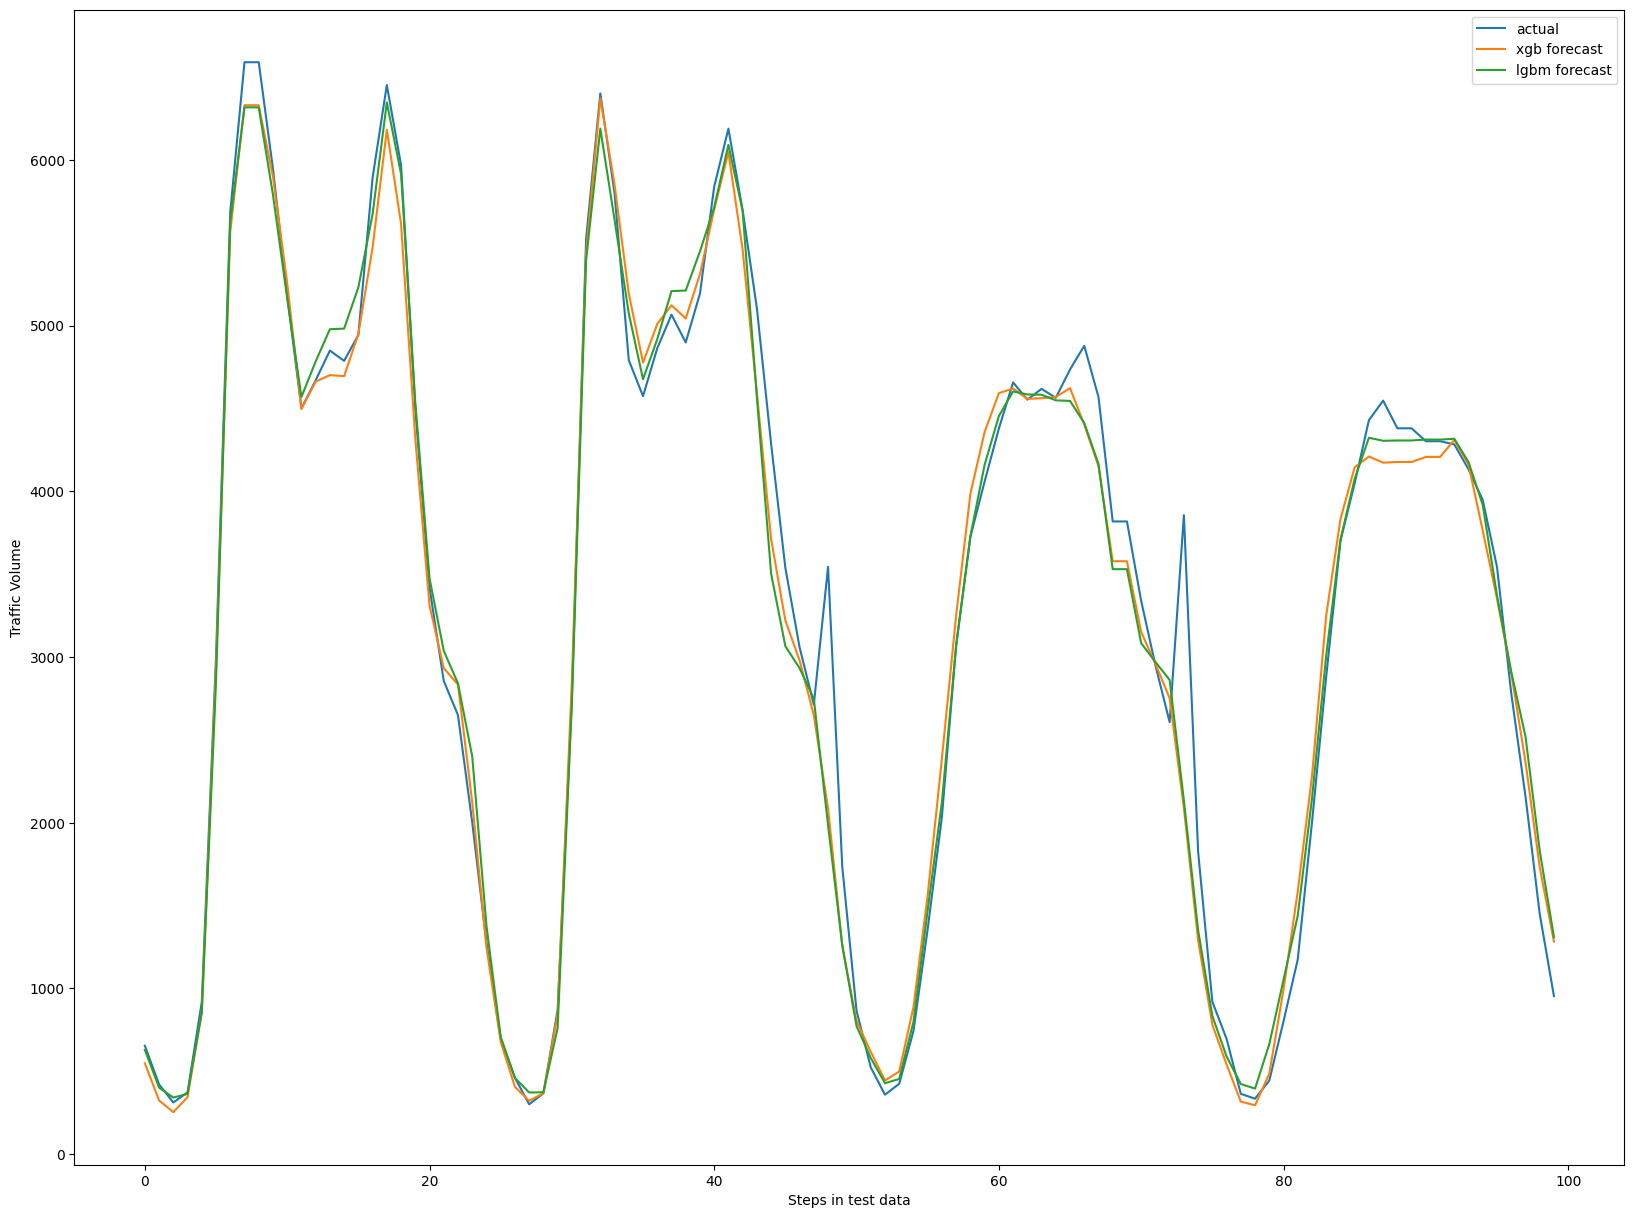

In [6]:
# Create a graph to compare the XGBoost and LightGBM forecast to the actuals
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plt.plot(list(y_test))
plt.plot(list(xgb_fcst))
plt.plot(list(lgbm_fcst))
plt.legend(['actual', 'xgb forecast', 'lgbm forecast'])
plt.ylabel('Traffic Volume')
plt.xlabel('Steps in test data')
plt.show()

### Hyperparameter Tuning Using Bayesian Optimization

Rather than using GridSearchCV, we’ll be using Bayesian optimization here.

In Bayesian optimization, rather than trying out every combination of hyperparameters or just trying out random guesses, it allows you to make intelligent guesses by modeling the likelihood of a certain value for the hyperparameters to be the optimum. This is done by modeling a probability distribution around the hyperparameters.

***READ MORE ON PAGE 201***

### Bayesian Optimization Using scikit-optimize

In [8]:
# Applying Bayesian optimization to XGBoost
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import random

random.seed(0)

xgb_model=XGBRegressor()
searchspaces={
'learning_rate': (10e-6, 1.0, 'log-uniform'),
'max_depth': Integer(0, 50, 'uniform'),
'n_estimators' : (10, 1000, 'log-uniform'),
}

xgb_opt = BayesSearchCV(
estimator=xgb_model,
search_spaces=searchspaces,
n_iter=10,
cv=3
)

xgb_opt.fit(X_train, y_train)

xgb_tuned_fcst = xgb_opt.best_estimator_.predict(X_test)

print("train_score",r2_score(list(y_train), list(xgb_opt.best_estimator_.predict(X_train))))
print("test_score",r2_score(list(y_test), list(xgb_tuned_fcst)))

train_score 0.9585574733968231
test_score 0.9689812338034185


Not better but still very good.

In [11]:
# Applying Bayesian optimization to LightGBM
import random
import warnings

warnings.filterwarnings("ignore")

random.seed(0)

lgbm=LGBMRegressor()
searchspaces={
'learning_rate': (10e-6, 1.0, 'log-uniform'),
'max_depth': Integer(-1, 50, 'uniform'),
'n_estimators' : (10, 1000, 'log-uniform'),
}

lgbm_opt = BayesSearchCV(
estimator=lgbm,
search_spaces=searchspaces,
n_iter=10,
cv=3
)

lgbm_opt.fit(X_train, y_train)

lgbm_tuned_fcst = lgbm_opt.best_estimator_.predict(X_test)

print("train_score",r2_score(list(y_train), list(lgbm_opt.best_estimator_.predict(X_train))))
print("test_score",r2_score(list(y_test), list(lgbm_tuned_fcst)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49
[LightGBM] [Info] Number of data points in the train set: 32069, number of used features: 4
[LightGBM] [Info] Start training from score 3257.167888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 51
[LightGBM] [Info] Number of data points in the train set: 32069, number of used features: 4
[LightGBM] [Info] Start training from score 3290.032025
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

Very good performance as well.

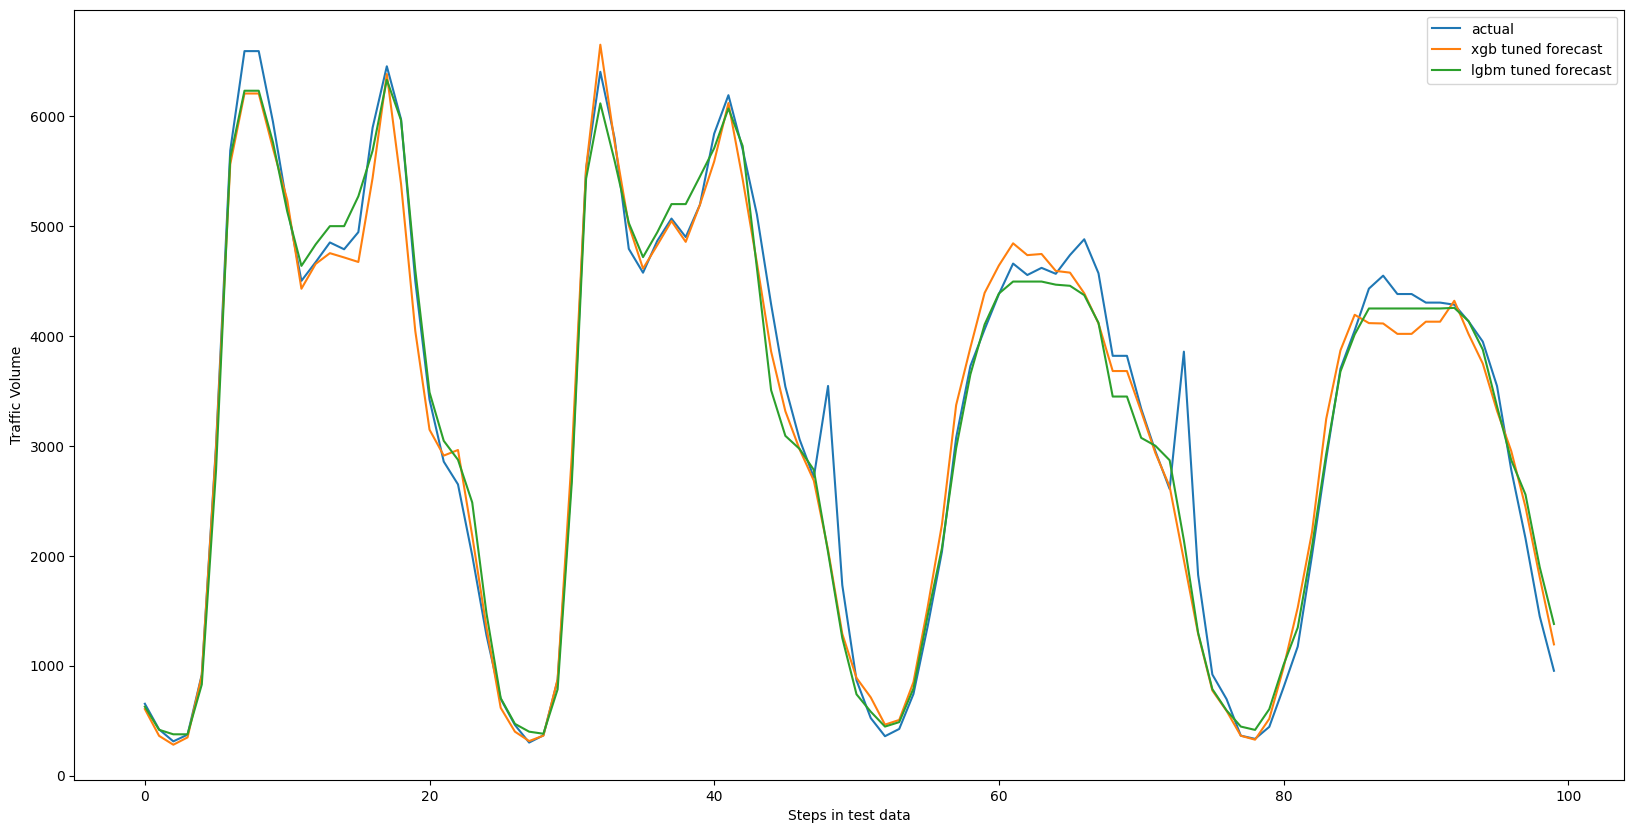

In [12]:
# Plotting the two tuned models
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plt.plot(list(y_test))
plt.plot(list(xgb_tuned_fcst))
plt.plot(list(lgbm_tuned_fcst))
plt.legend(['actual', 'xgb tuned forecast', 'lgbm tuned forecast'])
plt.ylabel('Traffic Volume')
plt.xlabel('Steps in test data')
plt.show()

In the current execution, n_iter, or the number of iterations, was fixed at 20. The execution with this number of iterations is relatively fast. If you want to play around with it, you could test if higher values for n_iter allow the Bayesian optimization to find even higher scores.


### Key Takeaways
* Gradient boosting is an ensemble learning technique that lets subsequent individual models from the ensemble learn on the parts that are not yet understood well by the model.
* You have seen two models of gradient boosting:
* XGBoost: A more traditional method for gradient boosting
* LightGBM: A newer but very performant competitor
* Bayesian optimization is a more intelligent method for tuning hyperparameters. It estimates the probability of the optimum being on a certain location and therefore makes intelligent guesses for the optimum.